Calculating mathematical distances for 1 to 10 regimes. Please wait a moment...


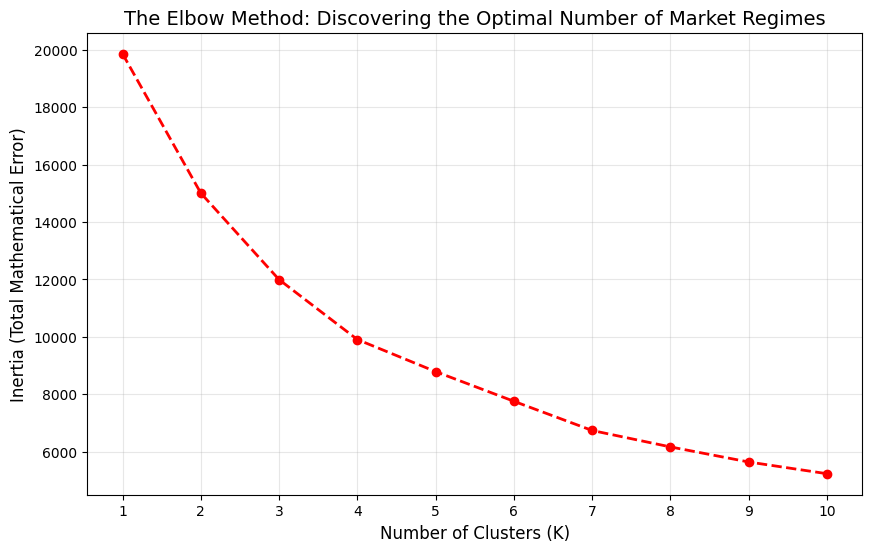

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load your clean, engineered data
df = pd.read_csv('../data/sp500_engineered_features.csv', index_col='Date', parse_dates=True)

# 2. Isolate the variables the algorithm will learn from
features = ['Returns', 'Volatility', 'Abnormal_Volume']
X = df[features]

# 3. Feature Scaling (Compressing everything to a standard scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. The Elbow Method (Testing K=1 through K=10)
inertia = []
K_range = range(1, 11)

print("Calculating mathematical distances for 1 to 10 regimes. Please wait a moment...")
for k in K_range:
    # random_state ensures we get the exact same reproducible results every time
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) 
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_) # inertia_ is the total mathematical error/distance

# 5. Plot the Results
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='red', linewidth=2)
plt.title('The Elbow Method: Discovering the Optimal Number of Market Regimes', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Total Mathematical Error)', fontsize=12)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)

plt.show()